In [1]:
#Standard Library
import sys
sys.path.append("../src")
import os

#Third Party Libraries
import pandas as pd

#Local Imports
from strategies.macd import MACDStrategy
from data.cleaner import fetch_raw_data, clean_data


In [2]:
ticker = "AAPL"
if os.path.exists(f"../data/cleaned/{ticker}_cleaned.csv"):
    df = pd.read_csv(f"../data/cleaned/{ticker}_cleaned.csv")
else:
    raw_df = fetch_raw_data(ticker, start_date='2020-01-01', end_date='2023-01-01')
    if raw_df is None:
        print(f"Skipping {ticker} - no data available")
    df = clean_data(ticker)

strategy = MACDStrategy("MACD", df, ticker, 10000)
results = strategy.backtest()
for key, value in results.items():
    print(f"{key}: {value}")


strategy: MACD
ticker: AAPL
starting_capital: 10000
final_capital: 10110.367195129395
total_return: 110.36719512939453
percent_return: 1.1036719512939452
win_rate: 50.0
risk/reward: 2.68


c:\Users\almon\algorithmic-trading-bot\notebooks\../src\strategies\base_strategy.py:150: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  trades_df = pd.read_sql("SELECT Strategy, Ticker, Side, Profit, Trade_Type, Date FROM Trades "


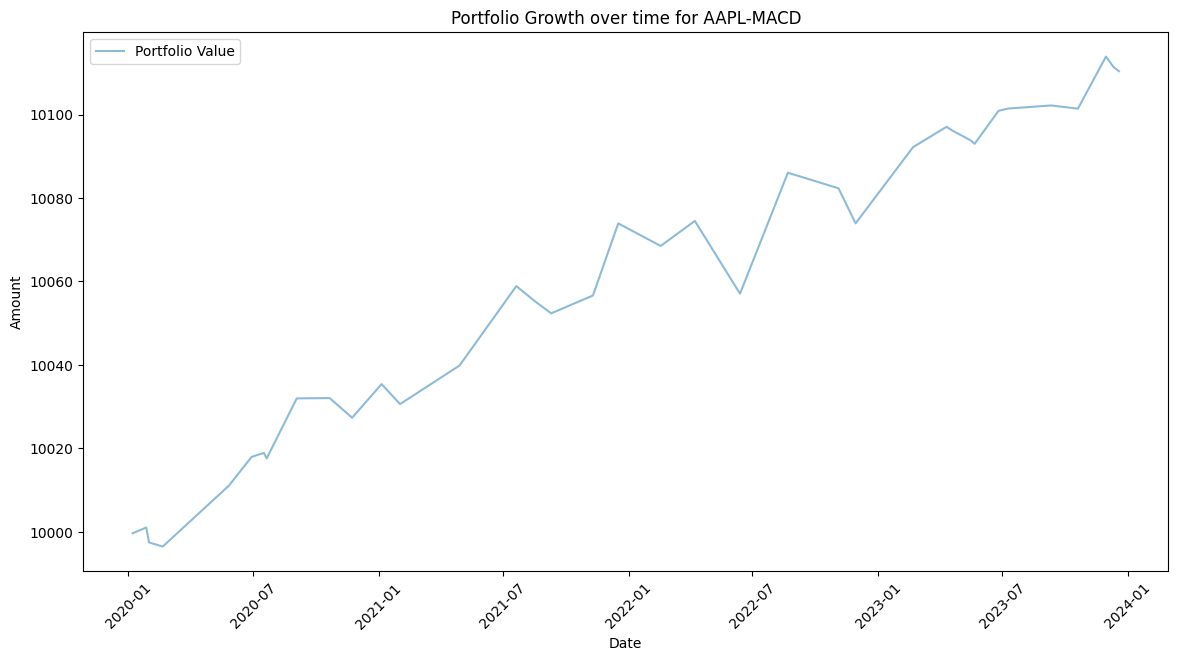

In [3]:
strategy.plot_portfolio_growth()